In [14]:
"""
LinearSVC + TF-IDF (word+char) with:
- Grouped split by claim_id (prevents paraphrase leakage)
- Unicode normalization + duplicate pruning
- Class weights (balanced)
- Probability calibration via CalibratedClassifierCV (sigmoid)
- Threshold tuning on validation
- Train/Val/Test confusion matrices + ROC/PR plots
- Optional negation-only diagnostics if 'variant' column exists
- Saves splits, model, metrics, and test predictions
"""

# ============== 1) CONFIG ==============
RAW_PATH = r"C:/Users/admin/Documents/PSM1_LAVEN/Datasets/Final_dataset_CVD19_ready_hardneg_bulk.csv"
OUT_DIR  = r"C:/Users/admin/Documents/PSM1_LAVEN/Model/SVM_TFIDF/outputs_svc_tfidf"
SEED     = 42

# ============== 2) IMPORTS ==============
import os, json, unicodedata
import numpy as np, pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    roc_auc_score, confusion_matrix, average_precision_score,
    ConfusionMatrixDisplay, roc_curve, precision_recall_curve
)
import sklearn, joblib
import matplotlib.pyplot as plt

os.makedirs(OUT_DIR, exist_ok=True)
np.random.seed(SEED)
print("scikit-learn:", sklearn.__version__)

# ============== 3) HELPERS ==============
def evaluate_split(y_true, proba_real, thr):
    """Return metrics dict + predicted labels at threshold `thr` (positive=real=1)."""
    preds = (proba_real >= thr).astype(int)
    acc = accuracy_score(y_true, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, preds, average="macro", zero_division=0)
    p_pc, r_pc, f1_pc, _ = precision_recall_fscore_support(y_true, preds, average=None, zero_division=0)
    cm = confusion_matrix(y_true, preds).tolist()
    try:
        roc = roc_auc_score(y_true, proba_real)
    except Exception:
        roc = float("nan")
    try:
        pr_auc = average_precision_score(y_true, proba_real)
    except Exception:
        pr_auc = float("nan")
    return {
        "threshold": float(thr),
        "accuracy": float(acc),
        "macro_precision": float(prec),
        "macro_recall": float(rec),
        "macro_f1": float(f1),
        "per_class_precision_[fake,real]": [float(x) for x in p_pc],
        "per_class_recall_[fake,real]": [float(x) for x in r_pc],
        "per_class_f1_[fake,real]": [float(x) for x in f1_pc],
        "confusion_matrix_[[tn,fp],[fn,tp]]": cm,
        "roc_auc": float(roc),
        "pr_auc": float(pr_auc)
    }, preds

def save_confusion(y_true, proba, thr, title, path):
    preds = (proba >= thr).astype(int)
    cm = confusion_matrix(y_true, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=["fake", "real"])
    fig, ax = plt.subplots(figsize=(4, 4), dpi=160)
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(path)
    plt.close(fig)

def save_roc_pr(y_true, proba, title_prefix, out_dir):
    try:
        fpr, tpr, _ = roc_curve(y_true, proba)
        precision, recall, _ = precision_recall_curve(y_true, proba)
    except Exception:
        return
    fig = plt.figure(figsize=(10, 4), dpi=160)

    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(f"{title_prefix} ROC")

    plt.subplot(1, 2, 2)
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title_prefix} PR")

    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{title_prefix.lower()}_roc_pr.png"))
    plt.close(fig)

# ============== 4) LOAD & CLEAN ==============
df = pd.read_csv(RAW_PATH, encoding="latin-1")
assert {"claim_id","text","label"}.issubset(df.columns), "Dataset must have claim_id, text, label"

# normalize text; drop exact duplicates (text+label)
df["text_clean"] = df["text"].astype(str).apply(lambda x: unicodedata.normalize("NFKC", x))
before = len(df)
df = df.drop_duplicates(subset=["text_clean","label"]).reset_index(drop=True)
print(f"Removed duplicates: {before - len(df)} | Remaining: {len(df)}")

# make sure claim_id is numeric; drop rows without it
df["claim_id"] = pd.to_numeric(df["claim_id"], errors="coerce").astype("Int64")
df = df.dropna(subset=["claim_id"]).reset_index(drop=True)

# ============== 5) GROUPED SPLITS ==============
groups = df["claim_id"]

gss1 = GroupShuffleSplit(test_size=0.20, n_splits=1, random_state=SEED)
train_idx, test_idx = next(gss1.split(df, groups=groups))
train_df = df.iloc[train_idx].copy()
test_df  = df.iloc[test_idx].copy()

gss2 = GroupShuffleSplit(test_size=0.10, n_splits=1, random_state=SEED)
train_idx2, val_idx = next(gss2.split(train_df, groups=train_df["claim_id"]))
final_train = train_df.iloc[train_idx2].copy()
final_val   = train_df.iloc[val_idx].copy()

for name, d in [("train", final_train), ("val", final_val), ("test", test_df)]:
    d.to_csv(os.path.join(OUT_DIR, f"{name}_clean.csv"), index=False, encoding="utf-8")

print({"train": len(final_train), "val": len(final_val), "test": len(test_df)})

# ============== 6) LABELS ==============
label_map = {"fake":0, "real":1}
y_train = final_train["label"].map(label_map).values
y_val   = final_val["label"].map(label_map).values
y_test  = test_df["label"].map(label_map).values

# ============== 7) FEATURES & MODEL ==============
# Word 1–2 grams + Char 2–6 grams
word_vec = TfidfVectorizer(
    analyzer="word", ngram_range=(1,2), min_df=2, max_features=100_000,
    sublinear_tf=True, lowercase=True, strip_accents="unicode"
)
char_vec = TfidfVectorizer(
    analyzer="char", ngram_range=(2,6), min_df=2, max_features=120_000,
    sublinear_tf=True, lowercase=True
)
feats = FeatureUnion([("word_tfidf", word_vec), ("char_tfidf", char_vec)])

# Class weights (balanced) for LinearSVC
cw_vals = compute_class_weight(class_weight="balanced", classes=np.array([0,1]), y=y_train)
class_weight = {0: float(cw_vals[0]), 1: float(cw_vals[1])}

svc = LinearSVC(C=1.0, class_weight=class_weight, random_state=SEED)

# Calibrate to get well-behaved probabilities and enable threshold tuning
try:
    cal = CalibratedClassifierCV(estimator=svc, method="sigmoid", cv=5)
except TypeError:
    cal = CalibratedClassifierCV(base_estimator=svc, method="sigmoid", cv=5)

pipeline = Pipeline([("tfidf", feats), ("cal", cal)])

# ============== 8) TRAIN ==============
pipeline.fit(final_train["text_clean"], y_train)

# ============== 9) THRESHOLD TUNING (VAL) ==============
val_proba = pipeline.predict_proba(final_val["text_clean"])[:, 1]
best_thr, best_f1 = 0.5, -1.0
for thr in np.linspace(0.10, 0.90, 81):
    _, _, f1, _ = precision_recall_fscore_support(
        y_val, (val_proba >= thr).astype(int), average="macro", zero_division=0
    )
    if f1 > best_f1:
        best_f1, best_thr = f1, thr
print(f"Best threshold on val: {best_thr:.2f} | macro-F1: {best_f1:.3f}")

# ============== 10) EVALUATION (TRAIN / VAL / TEST) ==============
# TRAIN
train_proba = pipeline.predict_proba(final_train["text_clean"])[:, 1]
train_metrics, _ = evaluate_split(y_train, train_proba, best_thr)

# VAL
val_metrics, _ = evaluate_split(y_val, val_proba, best_thr)

# TEST
test_proba = pipeline.predict_proba(test_df["text_clean"])[:, 1]
test_metrics, test_preds = evaluate_split(y_test, test_proba, best_thr)

print("TRAIN:", {k:v for k,v in train_metrics.items() if k in ["accuracy","macro_precision","macro_recall","macro_f1","roc_auc","pr_auc"]})
print("VAL  :", {k:v for k,v in val_metrics.items()   if k in ["accuracy","macro_precision","macro_recall","macro_f1","roc_auc","pr_auc"]})
print("TEST :", {k:v for k,v in test_metrics.items()  if k in ["accuracy","macro_precision","macro_recall","macro_f1","roc_auc","pr_auc"]})

# Negation-only diagnostics if you have a 'variant' column
if "variant" in test_df.columns:
    neg_mask = test_df["variant"].astype(str).str.contains("neg", case=False, na=False)
    if neg_mask.any():
        neg_y  = y_test[neg_mask.values]
        neg_pr = test_proba[neg_mask.values]
        neg_m, _ = evaluate_split(neg_y, neg_pr, best_thr)
        print("NEGATION subset (test, global thr):",
              {k:v for k,v in neg_m.items() if k in ["accuracy","macro_f1","roc_auc","pr_auc"]},
              f"| n={int(neg_mask.sum())}")

# Paraphrase consistency on TEST (same claim_id => all predictions identical)
test_eval = test_df.copy()
test_eval["pred"] = (test_proba >= best_thr).astype(int)
multi = test_eval.groupby("claim_id").filter(lambda g: len(g) > 1).groupby("claim_id")
consistent = sum(1 for _, g in multi if g["pred"].nunique()==1)
multi_total = len(list(multi.groups.keys()))
para_consistency = float(consistent/multi_total) if multi_total>0 else float("nan")
print(f"Paraphrase consistency (test): {para_consistency:.3f} over {multi_total} multi-variant claims")

# ============== 11) PLOTS (Train / Val / Test) ==============
save_confusion(y_train, train_proba, best_thr, "Train Confusion Matrix", os.path.join(OUT_DIR, "cm_train.png"))
save_confusion(y_val,   val_proba,   best_thr, "Val Confusion Matrix",   os.path.join(OUT_DIR, "cm_val.png"))
save_confusion(y_test,  test_proba,  best_thr, "Test Confusion Matrix",  os.path.join(OUT_DIR, "cm_test.png"))

save_roc_pr(y_train, train_proba, "Train", OUT_DIR)
save_roc_pr(y_val,   val_proba,   "Val",   OUT_DIR)
save_roc_pr(y_test,  test_proba,  "Test",  OUT_DIR)

# ============== 12) SAVE ARTIFACTS ==============
model_path = os.path.join(OUT_DIR, "svc_tfidf_calibrated.joblib")
joblib.dump(pipeline, model_path)

metrics = {
    "vectorizers": {
        "word_ngrams":[1,2], "char_ngrams":[2,6],
        "min_df":2, "max_features_word":100000, "max_features_char":120000,
        "sublinear_tf": True
    },
    "class_weight": {"0": class_weight[0], "1": class_weight[1]},
    "best_threshold": float(best_thr),
    "train": train_metrics,                 # added
    "val": val_metrics,
    "test": test_metrics,
    "paraphrase_consistency_test": float(para_consistency)
}
with open(os.path.join(OUT_DIR, "svc_metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2)

preds_out = pd.DataFrame({
    "claim_id": test_df["claim_id"],
    "text_clean": test_df["text_clean"],
    "true_label": test_df["label"],
    "proba_real": test_proba,
    "pred_label": np.where(test_proba >= best_thr, "real", "fake")
})
preds_out.to_csv(os.path.join(OUT_DIR, "svc_test_predictions.csv"), index=False, encoding="utf-8")

print("Saved:", {
    "model": model_path,
    "metrics": os.path.join(OUT_DIR, "svc_metrics.json"),
    "predictions_csv": os.path.join(OUT_DIR, "svc_test_predictions.csv"),
    "plots": {
        "cm_train": os.path.join(OUT_DIR, "cm_train.png"),
        "cm_val":   os.path.join(OUT_DIR, "cm_val.png"),
        "cm_test":  os.path.join(OUT_DIR, "cm_test.png"),
        "rocpr_train": os.path.join(OUT_DIR, "train_roc_pr.png"),
        "rocpr_val":   os.path.join(OUT_DIR, "val_roc_pr.png"),
        "rocpr_test":  os.path.join(OUT_DIR, "test_roc_pr.png"),
    },
    "splits": {
        "train": os.path.join(OUT_DIR, "train_clean.csv"),
        "val":   os.path.join(OUT_DIR, "val_clean.csv"),
        "test":  os.path.join(OUT_DIR, "test_clean.csv"),
    }
})


scikit-learn: 1.6.1
Removed duplicates: 0 | Remaining: 24537
{'train': 17668, 'val': 1941, 'test': 4928}
Best threshold on val: 0.49 | macro-F1: 0.800
TRAIN: {'accuracy': 0.9226284808693683, 'macro_precision': 0.9224255682484683, 'macro_recall': 0.9229540480830378, 'macro_f1': 0.9225701340477301, 'roc_auc': 0.9827805613124945, 'pr_auc': 0.9814495660484804}
VAL  : {'accuracy': 0.8001030396702731, 'macro_precision': 0.7992703328183408, 'macro_recall': 0.8007550711823576, 'macro_f1': 0.799560320231657, 'roc_auc': 0.8675560723911548, 'pr_auc': 0.8223524694006905}
TEST : {'accuracy': 0.8017451298701299, 'macro_precision': 0.8012695410273659, 'macro_recall': 0.8007685699180545, 'macro_f1': 0.8009827895063024, 'roc_auc': 0.8637231529209622, 'pr_auc': 0.8330342109053187}
NEGATION subset (test, global thr): {'accuracy': 0.5052531041069723, 'macro_f1': 0.5052165440532492, 'roc_auc': 0.4955760486946319, 'pr_auc': 0.5259432572454015} | n=1047
Paraphrase consistency (test): 0.501 over 735 multi-var

In [13]:
# ===== SVM TF-IDF — post-hoc plots (no training) =====
import os, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, confusion_matrix,
    classification_report
)
from sklearn.calibration import calibration_curve
import joblib

# --- CONFIG: change to your SVM directory ---
OUT_DIR = r"C:/Users/admin/Documents/PSM1_LAVEN/Model/SVM_TFIDF/outputs_svc_tfidf"

# --- load artifacts ---
metrics_path = os.path.join(OUT_DIR, "svc_metrics.json")
preds_path   = os.path.join(OUT_DIR, "svc_test_predictions.csv")
model_path   = os.path.join(OUT_DIR, "svc_tfidf_calibrated.joblib")

with open(metrics_path, "r") as f:
    MET = json.load(f)
THR = float(MET.get("best_threshold", 0.5))

preds = pd.read_csv(preds_path)
y_true = (preds["true_label"].astype(str).str.lower() == "real").astype(int).values
proba  = preds["proba_real"].values
y_hat  = (proba >= THR).astype(int)

# --- helper to save cleanly ---
def savefig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=160)
    plt.close()

# ---------- 1) Confusion matrix ----------
cm = confusion_matrix(y_true, y_hat)
fig, ax = plt.subplots(figsize=(4.2, 3.8))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Confusion Matrix (test)")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(["fake (0)", "real (1)"])
ax.set_yticklabels(["fake (0)", "real (1)"])
for (i,j), v in np.ndenumerate(cm):
    ax.text(j, i, str(v), ha="center", va="center", color="black", fontsize=11)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
savefig(os.path.join(OUT_DIR, "svc_cm.png"))

# ---------- 2) ROC curve ----------
fpr, tpr, _ = roc_curve(y_true, proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(4.6, 4.2))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1], linestyle="--", lw=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC (test)"); plt.legend(loc="lower right")
savefig(os.path.join(OUT_DIR, "svc_roc.png"))

# ---------- 3) Precision–Recall curve ----------
prec, rec, _ = precision_recall_curve(y_true, proba)
ap = np.trapz(prec[::-1], rec[::-1])  # area under PR (approx.)
plt.figure(figsize=(4.6, 4.2))
plt.plot(rec, prec, lw=2, label=f"AP≈{ap:.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision–Recall (test)"); plt.legend(loc="lower left")
savefig(os.path.join(OUT_DIR, "svc_pr.png"))

# ---------- 4) Calibration curve ----------
prob_true, prob_pred = calibration_curve(y_true, proba, n_bins=10, strategy="quantile")
plt.figure(figsize=(4.6, 4.2))
plt.plot([0,1],[0,1], "--", lw=1, label="Perfect")
plt.plot(prob_pred, prob_true, marker="o", lw=2, label="SVM calibrated")
plt.xlabel("Predicted probability (bin mean)")
plt.ylabel("Empirical fraction of real")
plt.title("Reliability / Calibration (test)")
plt.legend(loc="upper left")
savefig(os.path.join(OUT_DIR, "svc_calibration.png"))

# ---------- 5) Metrics table figure ----------
report = classification_report(y_true, y_hat, target_names=["fake","real"], zero_division=0, output_dict=True)
tbl = pd.DataFrame(report).T[["precision","recall","f1-score","support"]]
plt.figure(figsize=(6.6, 2.4))
plt.axis("off")
plt.title("Classification report (test)", pad=10)
# draw a simple table
cell_text = [[f"{v:.3f}" if i<3 else f"{int(v)}" for i,v in enumerate(row)] for _, row in tbl.iterrows()]
col_labels = ["precision", "recall", "f1", "support"]
row_labels = list(tbl.index)
plt.table(cellText=cell_text, rowLabels=row_labels, colLabels=col_labels,
          cellLoc="center", rowLoc="center", loc="center")
savefig(os.path.join(OUT_DIR, "svc_report_table.png"))

# ---------- 6) Top features for 'real' vs 'fake' ----------
try:
    pipe = joblib.load(model_path)
    union = pipe.named_steps["tfidf"]
    feat_names = union.get_feature_names_out()  # sklearn >=1.0
    # CalibratedClassifierCV keeps a list of calibrated classifiers (one per CV fold)
    cal = pipe.named_steps["cal"]
    coefs = []
    for cc in cal.calibrated_classifiers_:
        base = cc.base_estimator  # LinearSVC
        coefs.append(base.coef_.ravel())
    coef = np.mean(np.vstack(coefs), axis=0)

    top_k = 25
    idx_real = np.argsort(coef)[-top_k:][::-1]
    idx_fake = np.argsort(coef)[:top_k]

    def barplot(idx, title, fname):
        xs = coef[idx]
        labs = feat_names[idx]
        plt.figure(figsize=(7.5, 6))
        order = np.argsort(xs)
        xs = xs[order]; labs = labs[order]
        plt.barh(range(len(xs)), xs)
        plt.yticks(range(len(xs)), labs, fontsize=8)
        plt.title(title)
        plt.xlabel("weight")
        savefig(os.path.join(OUT_DIR, fname))

    barplot(idx_real, "Top tokens pushing → REAL (class 1)", "svc_top_tokens_real.png")
    barplot(idx_fake, "Top tokens pushing → FAKE (class 0)", "svc_top_tokens_fake.png")
except Exception as e:
    print("Top-feature plot skipped:", e)

# ---------- 7) Word clouds (optional) ----------
try:
    from wordcloud import WordCloud, STOPWORDS
    # use train split to avoid test leakage
    train_csv = os.path.join(OUT_DIR, "train_clean.csv")
    if os.path.exists(train_csv):
        train_df = pd.read_csv(train_csv)
        real_text = " ".join(train_df.loc[train_df["label"].str.lower()=="real", "text_clean"].astype(str).tolist())
        fake_text = " ".join(train_df.loc[train_df["label"].str.lower()=="fake", "text_clean"].astype(str).tolist())
        wc_args = dict(width=900, height=600, background_color="white", stopwords=set(STOPWORDS))
        WordCloud(**wc_args).generate(real_text).to_file(os.path.join(OUT_DIR, "svc_wordcloud_real.png"))
        WordCloud(**wc_args).generate(fake_text).to_file(os.path.join(OUT_DIR, "svc_wordcloud_fake.png"))
        print("Word clouds saved.")
    else:
        print("train_clean.csv not found; skipping word clouds.")
except Exception as e:
    print("Word clouds skipped:", e)

print("Saved figures to:", OUT_DIR)


Top-feature plot skipped: '_CalibratedClassifier' object has no attribute 'base_estimator'
Word clouds saved.
Saved figures to: C:/Users/admin/Documents/PSM1_LAVEN/Model/SVM_TFIDF/outputs_svc_tfidf


=== 10 random examples ===


,claim_id,text_short,label,pred_label,proba_real,correct
1665,3562,False image and note spread claiming to be written by a university president that the heat from a hair dryer can kill coronavirus germs,fake,fake,0.264765,True
3592,11656,"n.b. covid-19 roundup: no new cases for 9th straight day, but province isn't ready to 'declare victory'",real,real,0.681473,True
2726,8063,spraying with boiling water eliminates the new coronavirus.,fake,fake,0.386937,True
2380,6505,"a message of key takeaways from an interview of hdfc bank md & ceo aditya puri, where he has said how india will survive the coronavirus pandemic.",fake,fake,0.268605,True
676,519,"As a point of comparison, cigarettes are approved by the FDA.",fake,fake,0.396504,True
290,218,"Individual studies on sun exposure and health undergo peer review; alleging they are a ""cover-upÂ for vaccine side effects conflates unrelated research topics without evidence.",real,real,0.690493,True
577,430,Reports suggest the UK's Prime Minister's booster was not a fake.,real,real,0.518258,True
2561,7297,"a french doctor is not quoted as saying that us billionaire bill gates wants to sell a covid-19 vaccine in africa, but it's poisonous and will destroy africa.",real,fake,0.368582,False
1519,2968,It is not true that Cebu City looking for own quarantine facility for residents with suspected 2019-nCov,fake,real,0.591647,False
2194,5727,"coronavirus outbreak updates: maharashtras cases sur..est positive; toll mounts to 5,984 with 160 fatalities",real,real,0.601773,True



=== 5 most confident REAL (highest proba_real) ===


,claim_id,text_short,label,pred_label,proba_real,correct
3595,11662,cbc windsor april 29 covid-19 update: 6 more people have not died,fake,real,0.770735,False
4203,14177,Masks remained recommended in long-term care homes across Canada in 2025.,real,real,0.770246,True
4434,14385,"Boosters must remain free for vulnerable populations, WHO stressed.",real,real,0.767246,True
4202,14177,"In 2025, Canada reminded visitors to senior centers to wear masks.",real,real,0.767183,True
4349,14316,Pfizer boosters lower severe illness risk in seniors above 65.,real,real,0.762815,True



=== 5 most confident FAKE (lowest proba_real) ===


,claim_id,text_short,label,pred_label,proba_real,correct
2874,8635,It is not false that tea can cure coronavirus.,fake,fake,0.155694,True
1311,2062,It is not false that Corona alienated Chinese cities,fake,fake,0.186629,True
1995,4878,"It is not false that no, this is the italian president crying over covid-19 deaths",fake,fake,0.187263,True
2769,8223,video shows the suicide of an american man because he is infected with coronavirus.,fake,fake,0.188375,True
2490,6934,It is not false that wine will protect you from covid-19.,fake,fake,0.198379,True



=== Top 5 MISCLASSIFICATIONS (n=978) ===


C:\Users\admin\AppData\Local\Temp\ipykernel_19256\188528225.py:131: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mistakes["conf_margin"] = np.where(mistakes["pred_label"]=="real",


,claim_id,text_short,label,pred_label,proba_real
427,327,Dr. Fauci never said lockdowns were to force vaccine compliance.,real,fake,0.213447
3595,11662,cbc windsor april 29 covid-19 update: 6 more people have not died,fake,real,0.770735
128,96,"Some allege that you can become vaccinated just by having contact with someone who's already received the shot, due to shedding.",real,fake,0.236750
1994,4878,"It is not true that no, this is the italian president crying over covid-19 deaths",real,fake,0.240352
1726,3835,"Several facebook posts claimed that onions pull the viruses, thus, putting an onion into every room may not be protective",real,fake,0.241511


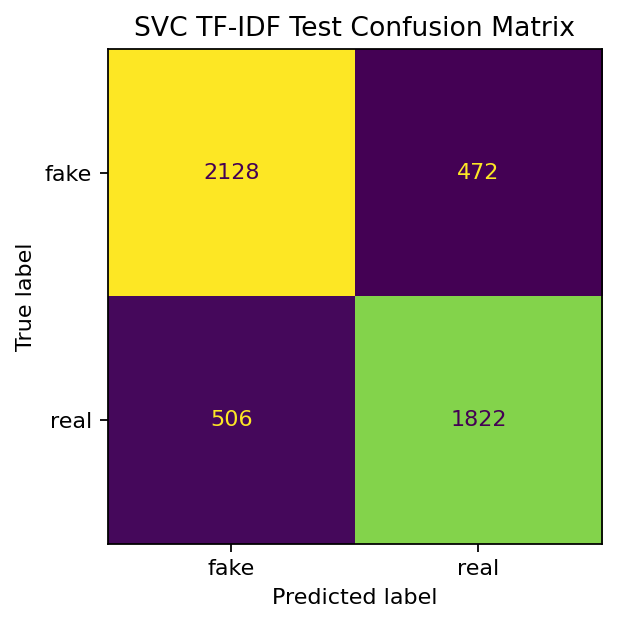

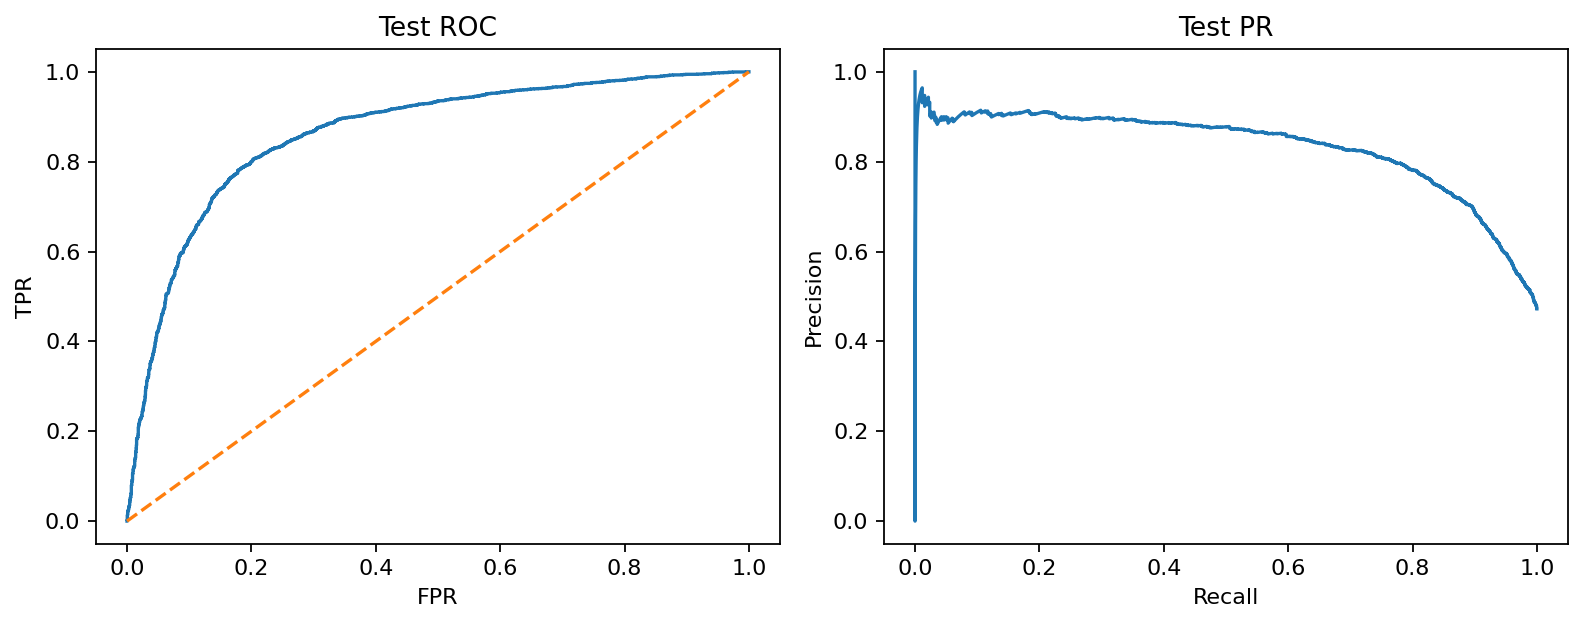


Summary: {'accuracy': 0.8015422077922078, 'macro_precision': 0.8010712968828921, 'macro_recall': 0.800553793285752, 'macro_f1': 0.8007740554676368, 'roc_auc': 0.8637021708961141, 'pr_auc': 0.8330284826340404}
Artifacts saved to: C:/Users/admin/Documents/PSM1_LAVEN/Appendix_Evals/svc_examples


In [15]:
# Calibrated LinearSVC + TF-IDF: EXAMPLES + PLOTS on the SAME TEST TEXTS
import os, json, unicodedata, joblib, random
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, roc_auc_score, average_precision_score,
                             ConfusionMatrixDisplay, roc_curve, precision_recall_curve)

# --- Paths (same test texts as above) ---
DATA_CSV      = r"C:/Users/admin/Documents/PSM1_LAVEN/Model/Logistic Regression + TF-IDF/outputs_lr_tfidf/test_clean.csv"
PIPELINE_PATH = r"C:/Users/admin/Documents/PSM1_LAVEN/Model/SVM_TFIDF/outputs_svc_tfidf/svc_tfidf_calibrated.joblib"
METRICS_JSON  = r"C:/Users/admin/Documents/PSM1_LAVEN/Model/SVM_TFIDF/outputs_svc_tfidf/svc_metrics.json"
OUT_DIR       = r"C:/Users/admin/Documents/PSM1_LAVEN/Appendix_Evals/svc_examples"
ENCODING      = "latin-1"
os.makedirs(OUT_DIR, exist_ok=True)

# --- helpers ---
def normalize_text_series(s: pd.Series) -> pd.Series:
    return s.astype(str).apply(lambda x: unicodedata.normalize("NFKC", x))

def ensure_columns(df: pd.DataFrame):
    need = {"claim_id","text","label"}
    miss = need - set(df.columns)
    if miss: raise ValueError(f"Missing columns: {miss}")

def map_labels(df: pd.DataFrame) -> np.ndarray:
    labmap = {"fake":0, "real":1}
    y = df["label"].astype(str).str.lower().map(labmap)
    if y.isna().any():
        raise ValueError(f"Unknown labels: {df.loc[y.isna(),'label'].unique().tolist()}")
    return y.astype(int).values

def evaluate_split(y_true, proba_real, thr):
    preds = (proba_real >= thr).astype(int)
    acc = accuracy_score(y_true, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, preds, average="macro", zero_division=0)
    p_pc, r_pc, f1_pc, _ = precision_recall_fscore_support(y_true, preds, average=None, zero_division=0)
    cm = confusion_matrix(y_true, preds).tolist()
    try: roc = float(roc_auc_score(y_true, proba_real))
    except: roc = float("nan")
    try: pr = float(average_precision_score(y_true, proba_real))
    except: pr = float("nan")
    return ({
        "threshold": float(thr),
        "accuracy": float(acc),
        "macro_precision": float(prec),
        "macro_recall": float(rec),
        "macro_f1": float(f1),
        "per_class_precision_[fake,real]": [float(x) for x in p_pc],
        "per_class_recall_[fake,real]": [float(x) for x in r_pc],
        "per_class_f1_[fake,real]": [float(x) for x in f1_pc],
        "confusion_matrix_[[tn,fp],[fn,tp]]": cm,
        "roc_auc": roc, "pr_auc": pr
    }, preds)

def save_confusion(y_true, proba, thr, title, path):
    preds = (proba >= thr).astype(int)
    cm = confusion_matrix(y_true, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=["fake","real"])
    fig, ax = plt.subplots(figsize=(4,4), dpi=160)
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(title)
    plt.tight_layout(); plt.savefig(path); plt.show(); plt.close(fig)

def save_roc_pr(y_true, proba, title_prefix, out_dir):
    try:
        fpr, tpr, _ = roc_curve(y_true, proba)
        prec, rec, _ = precision_recall_curve(y_true, proba)
    except Exception:
        return
    fig = plt.figure(figsize=(10,4), dpi=160)
    plt.subplot(1,2,1); plt.plot(fpr,tpr); plt.plot([0,1],[0,1],"--")
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title(f"{title_prefix} ROC")
    plt.subplot(1,2,2); plt.plot(rec,prec)
    plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title(f"{title_prefix} PR")
    plt.tight_layout(); plt.savefig(os.path.join(out_dir, f"{title_prefix.lower()}_roc_pr.png")); plt.show(); plt.close(fig)

def shorten(s, n=220):
    s = str(s)
    return s if len(s) <= n else s[:n-1] + "…"

# --- load data ---
df = pd.read_csv(DATA_CSV, encoding=ENCODING)
ensure_columns(df)
if "text_clean" not in df.columns:
    df["text_clean"] = normalize_text_series(df["text"])
y_true = map_labels(df)

# --- load pipeline + threshold ---
pipe = joblib.load(PIPELINE_PATH)
thr = 0.5
if os.path.isfile(METRICS_JSON):
    m = json.load(open(METRICS_JSON, "r"))
    thr = float(m.get("best_threshold", thr))

# --- predict ---
if not hasattr(pipe, "predict_proba"):
    raise RuntimeError("SVC pipeline has no predict_proba(). Ensure CalibratedClassifierCV was used.")
proba = pipe.predict_proba(df["text_clean"])[:, 1]
metrics, preds = evaluate_split(y_true, proba, thr)

# --- results table + save ---
res = df[["claim_id","text","label"]].copy()
res["proba_real"] = proba
res["pred_label"] = np.where(proba >= thr, "real", "fake")
res["correct"]    = (res["pred_label"].str.lower() == res["label"].str.lower())
res["text_short"] = res["text"].apply(lambda s: shorten(s, 220))
res[["claim_id","text","label","proba_real","pred_label","correct"]].to_csv(
    os.path.join(OUT_DIR, "predictions_test.csv"), index=False, encoding="utf-8"
)

# --- show examples ---
pd.set_option("display.max_colwidth", 240)
print("=== 10 random examples ===")
display(res.sample(10, random_state=42)[["claim_id","text_short","label","pred_label","proba_real","correct"]])

print("\n=== 5 most confident REAL (highest proba_real) ===")
display(res.sort_values("proba_real", ascending=False).head(5)[
    ["claim_id","text_short","label","pred_label","proba_real","correct"]
])

print("\n=== 5 most confident FAKE (lowest proba_real) ===")
display(res.sort_values("proba_real", ascending=True).head(5)[
    ["claim_id","text_short","label","pred_label","proba_real","correct"]
])

mistakes = res[~res["correct"]]
if len(mistakes) > 0:
    print(f"\n=== Top 5 MISCLASSIFICATIONS (n={len(mistakes)}) ===")
    mistakes["conf_margin"] = np.where(mistakes["pred_label"]=="real",
                                       mistakes["proba_real"],
                                       1.0 - mistakes["proba_real"])
    display(mistakes.sort_values("conf_margin", ascending=False).head(5)[
        ["claim_id","text_short","label","pred_label","proba_real"]
    ])
else:
    print("\n=== No misclassifications in this split ===")

# --- plots + metrics json ---
save_confusion(y_true, proba, thr, "SVC TF-IDF Test Confusion Matrix", os.path.join(OUT_DIR, "cm_test.png"))
save_roc_pr(y_true, proba, "Test", OUT_DIR)

with open(os.path.join(OUT_DIR, "metrics_test.json"), "w") as f:
    json.dump({"model_type":"svc_tfidf_calibrated", "threshold_used":thr, "test":metrics}, f, indent=2)

print("\nSummary:", {k: metrics[k] for k in ["accuracy","macro_precision","macro_recall","macro_f1","roc_auc","pr_auc"]})
print("Artifacts saved to:", OUT_DIR)
